In [1]:
# ============================================================
# Cell 1. Adjustable parameters
# ============================================================
# csv파일 저장할 폴더
folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] ionic DC-TENG\0. 실험자료\8. Gibeom touch\260506_이론 기반 파이썬\Figure S_comparison"

# ----------------------------
# Basic time parameters
# ----------------------------
R = 40*10**6          # Ohm
C = 23*10**(-9)       # F
tau = R * C         # tau = RC
#tau = 0.96
print (tau)
f = 3.95             # touch frequency, Hz
T = 1 / f           # touch period, s

# Because this value is hard to calculate directly,
# we use an experimentally representative value.
V_first = 3.86       # V __1.077은 del_V1 모를때... 역산해서 곱하는 경험 값
V_pump = 500            # Experimental value (Only postiive peak)

# ----------------------------
# Voltage jump parameters
# ----------------------------
# First voltage jump.
# This corresponds to:
# del_V1 = Q_TENG / C_CR
#     = (1/C_CR) * S*sigma*x_eff/(d0 + x_eff)
#
# Coupling factor:
# beta = C_eff / C_CR
beta = 0.016        # dimensionless
beta = V_first / V_pump
print(beta)
# Effective pump voltage.
# To make the model consistent with del_V1 = V_first:
# del_V1 = beta * V_pump
# Therefore, V_pump = V_first / beta

#V_pump = V_first / beta # If you defined the value of beta.



# ----------------------------
# Model options
# ----------------------------
# Case 1:
# Constant voltage increment model

# Case 2:
# First touch:
# V1 = V_first
#
# From the second touch:
# Vn = beta * (V_pump - Vn_minus)
# where Vn_minus is the reservoir voltage just before n-th touch.

# ----------------------------
# Plot options
# ----------------------------
t_start = 1.0       # first touch time, s
t_stop = 20       # last touch time, s
t_end = 30.0        # total simulation time, s
dt = 0.001          # time step, s
show_touch_lines = True
line_alpha = 0.4

0.92
0.007719999999999999


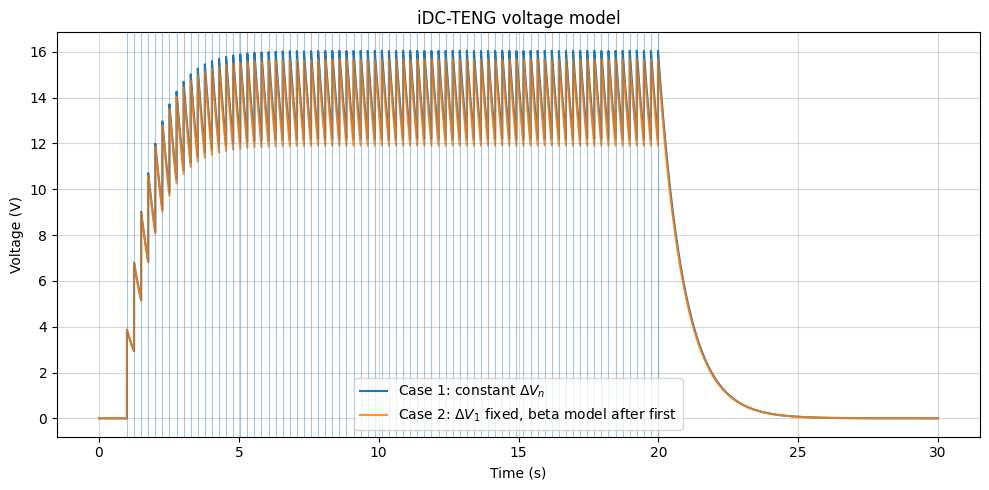

CSV exported to: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] ionic DC-TENG\0. 실험자료\8. Gibeom touch\260506_이론 기반 파이썬\Figure S_comparison\iDC-TENG_theory_case1_case2.csv


In [2]:
# ============================================================
# Cell 2. Calculation and plotting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1. Time array and touch times
# ----------------------------
t = np.arange(0, t_end + dt, dt)
touch_times = np.arange(t_start, t_stop + 1e-12, T)


# ----------------------------
# 2. Case 1: constant ?Vn
# ----------------------------
def simulate_constant_dVn(t, touch_times, tau, V_first):
    """
    Case 1: Constant voltage increment model.

    Every touch event increases the reservoir voltage by the same amount:
        ?Vn = V_first

    Between touch events, the voltage decays exponentially:
        V(t) = V0 * exp(-t/tau)
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    dV_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            # Constant voltage increment
            dV_n = V_first

            current_V += dV_n
            V_plus = current_V

            dV_list.append(dV_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(dV_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 3. Case 2: first ?V fixed, then beta model
# ----------------------------
def simulate_beta_dVn_after_first(t, touch_times, tau, V_first, beta, V_pump):
    """
    Case 2: Voltage-dependent increment model.

    First touch:
        ?V1 = V_first

    From the second touch:
        ?Vn = beta * (V_pump - Vn_minus),  n >= 2

    where:
        Vn_minus = reservoir voltage immediately before the n-th touch

    Physical meaning:
        V_pump is the transient pump voltage scale generated by the CP/TENG.
        Vn_minus acts as a pre-existing DC offset in the charge reservoir.
        beta = C_eff / C_CR converts the remaining driving voltage into
        the voltage increment of the charge reservoir.
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    dV_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            # Touch number: 1, 2, 3, ...
            n_touch = event_idx + 1

            if n_touch == 1:
                # First voltage jump is fixed by V_first
                dV_n = V_first
            else:
                # From second touch, use beta model
                dV_n = beta * (V_pump - V_minus)

                # Prevent negative charging
                dV_n = max(dV_n, 0.0)

            current_V += dV_n
            V_plus = current_V

            dV_list.append(dV_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(dV_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 4. Run simulations
# ----------------------------
V_const, dV_const, Vminus_const, Vplus_const = simulate_constant_dVn(
    t=t,
    touch_times=touch_times,
    tau=tau,
    V_first=V_first
)

V_beta, dV_beta, Vminus_beta, Vplus_beta = simulate_beta_dVn_after_first(
    t=t,
    touch_times=touch_times,
    tau=tau,
    V_first=V_first,
    beta=beta,
    V_pump=V_pump
)


# ----------------------------
# 5. Plot: comparison of both models
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_const, label="Case 1: constant $\\Delta V_n$")
plt.plot(t, V_beta, label="Case 2: $\\Delta V_1$ fixed, beta model after first", alpha=0.85)

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("iDC-TENG voltage model")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 6. Export Case 1 and Case 2 voltage traces to CSV
# ----------------------------


if not folder_path.strip():
    raise ValueError("Set folder_path to a valid folder path before exporting the CSV.")

output_dir = Path(folder_path)
csv_data = np.column_stack((t, V_const, V_beta))
csv_path = output_dir / "iDC-TENG_theory_case1_case2.csv"

np.savetxt(
    csv_path,
    csv_data,
    delimiter=",",
    header="Time,Case 1 Voltage,Case 2 Voltage",
    comments=""
)

print(f"CSV exported to: {csv_path.resolve()}")


